In [1]:
import os
from tensorboard.backend.event_processing import event_accumulator
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import pickle
import torch

def load_tensorboard_events(file_path):
    # Create an EventAccumulator to load the event file.
    # The 'size_guidance' argument can be used to control how many items to load for each type.
    ea = event_accumulator.EventAccumulator(
        file_path,
        size_guidance={
            'scalars': 1000,   # maximum number of scalar events to load per tag
            'images': 4,       # maximum number of image events to load per tag
            'histograms': 1,   # maximum number of histogram events to load per tag
            'compressedHistograms': 1,
            'audio': 1,
        }
    )
    ea.Reload()  # load events from file

    # Print available tags
    tags = ea.Tags()
    print("Available Tags:", tags)

    # For example, to print all scalar events for each scalar tag:
    if 'scalars' in tags:
        for tag in tags['scalars']:
            print(f"\nScalar values for tag: {tag}")
            events = ea.Scalars(tag)
            for event in events:
                print(f"Step: {event.step}, Value: {event.value}")
                

def load_tensorboard_metrics(file_path):
    ea = event_accumulator.EventAccumulator(
        file_path,
        size_guidance={
            'scalars': 100,   # maximum number of scalar events to load per tag
            'images': 4,       # maximum number of image events to load per tag
            'histograms': 1,   # maximum number of histogram events to load per tag
            'compressedHistograms': 1,
            'audio': 1,
        }
    )
    ea.Reload()  # load events from file
    tags = ea.Tags()
    metrics = tags['scalars']
    
    return_dict = {
        'best_model_epoch': None,
        'in-domain test metric (per sample)': None,
        'test metric (per sample)': None,
    }
    
    for tag in metrics:
        if 'in-domain test metric' in tag:
            return_dict['in-domain test metric (per sample)'] = ea.Scalars(tag)[0].value
            return_dict['best_model_epoch'] = ea.Scalars(tag)[0].step   
        elif 'test metric' in tag:
            return_dict['test metric (per sample)'] = ea.Scalars(tag)[0].value
    return return_dict  


def load_series_metrics(tensor_board_dir, model_metrics):
    unmatched_sub_fodlers = []
    sub_fodlers = os.listdir(tensor_board_dir)
    models = model_metrics.keys()
    for sub_folder in sub_fodlers:
        sub_folder_path = os.path.join(tensor_board_dir, sub_folder)
        files = os.listdir(sub_folder_path)
        # find the key that in the sub_folder
        key = None
        for model in models:
            if model in sub_folder:
                key = model
                break
        if key is None:
            unmatched_sub_fodlers.append(sub_folder)
            continue
        for file in files:
            if file.startswith("events.out.tfevents"):
                file_path = os.path.join(sub_folder_path, file)
                metrics = load_tensorboard_metrics(file_path)
                metrics['sub_folder'] = sub_folder
                model_metrics[key].append(metrics)
    return model_metrics, unmatched_sub_fodlers


def MPJPE_2D(predicts, labels, per_sample = True):
    # if the shape of the predicts and labels are : (batch_size, num_joints * 2)
    # reshape the predicts and labels to (batch_size, num_joints, dim)
    if isinstance(predicts, torch.Tensor):
        predicts = predicts.detach().cpu().numpy()
    if isinstance(labels, torch.Tensor):
        labels = labels.detach().cpu().numpy()
    predicts = predicts.reshape(predicts.shape[0], -1, 2)
    labels = labels.reshape(labels.shape[0], -1, 2)
    per_sample_mpjpe = np.mean(np.abs(np.linalg.norm(predicts - labels, axis=2)), axis=1)
    if per_sample:
        return per_sample_mpjpe
    return np.mean(per_sample_mpjpe, axis=0)

def MPJPE_3D(predicts, labels, per_sample = True):
    # if the shape of the predicts and labels are : (batch_size, num_joints * 3) 
    # reshape the predicts and labels to (batch_size, num_joints, dim)
    if isinstance(predicts, torch.Tensor):
        predicts = predicts.detach().cpu().numpy()
    if isinstance(labels, torch.Tensor):
        labels = labels.detach().cpu().numpy()
    predicts = predicts.reshape(predicts.shape[0], -1, 3)
    labels = labels.reshape(labels.shape[0], -1, 3)
    per_sample_mpjpe = np.mean(np.linalg.norm(predicts - labels, axis=2), axis=1)
    # if there is any value less than 0, print the index
    if np.any(per_sample_mpjpe < 0):
        print("less than 0")
        print(np.where(per_sample_mpjpe < 0))
    if per_sample:
        return per_sample_mpjpe
    return np.mean(per_sample_mpjpe, axis=0)

def accuracy(predicts, labels):
    # predicts: (batch_size, num_classes)
    # labels: (batch_size, )
    if isinstance(predicts, torch.Tensor):
        predicts = predicts.detach().cpu().numpy()
    if isinstance(labels, torch.Tensor):
        labels = labels.detach().cpu().numpy()
    predicts = np.argmax(predicts, axis=1)
    return np.sum(predicts == labels) / len(labels)

## Get the cross domain test results when using stft as input

In [ ]:
all_results_folder = 'logs/widar3G6/'

results_files = [
    'widar3G6_CRATEsmall_crate_small_0207102454_indomain_test',
]

model_names = [
    'Cross_room_user'
    ]

accuracy_cross_user_list = []
accuracy_cross_orientation_list = []
accuracy_cross_rx_list = []


for results_file in results_files:
    with open(all_results_folder + results_file + '.pkl', 'rb') as handle:
        results = pickle.load(handle)
        predicts = results['predicts']
        labels = results['labels']
        attributes = results['attributes']
        
        user_ids = []
        orientations = []
        rx_ids = []
        for i in range(len(attributes)):
            user_id = attributes[i][0].numpy()
            orientation = attributes[i][1].numpy()
            rx_id = attributes[i][2].numpy()
            user_ids.append(user_id)
            orientations.append(orientation)
            rx_ids.append(rx_id)
        
        user_ids = np.concatenate(user_ids, axis=0)
        orientations = np.concatenate(orientations, axis=0)
        rx_ids = np.concatenate(rx_ids, axis=0)
        predicts_np = np.concatenate(predicts, axis=0)
        labels_np = np.concatenate(labels, axis=0)

        # user ids
        user_ids_set = set(user_ids)
        cross_user_acc = {}
        for user_id in user_ids_set:
            user_id_index = np.where(user_ids == user_id)[0]
            predicts_np_user = predicts_np[user_id_index]
            labels_np_user = labels_np[user_id_index]
            cross_user_acc[user_id] = accuracy(predicts_np_user, labels_np_user)
        accuracy_cross_user_list.append(cross_user_acc)
        # print(cross_user_acc)
        # orientation
        orientation_set = set(orientations)
        cross_orientation_acc = {}
        for orientation in orientation_set:
            orientation_index = np.where(orientations == orientation)[0]
            predicts_np_orientation = predicts_np[orientation_index]
            labels_np_orientation = labels_np[orientation_index]
            cross_orientation_acc[orientation] = accuracy(predicts_np_orientation, labels_np_orientation)
        accuracy_cross_orientation_list.append(cross_orientation_acc)
        # print(cross_orientation_acc)
        # rx ids
        rx_ids_set = set(rx_ids)
        cross_rx_acc = {}
        for rx_id in rx_ids_set:
            rx_id_index = np.where(rx_ids == rx_id)[0]
            predicts_np_rx = predicts_np[rx_id_index]
            labels_np_rx = labels_np[rx_id_index]
            cross_rx_acc[rx_id] = accuracy(predicts_np_rx, labels_np_rx)
        accuracy_cross_rx_list.append(cross_rx_acc)
        # print(cross_rx_acc)
        # break

print('indomain test:')
for index, name in enumerate(model_names):
    print(name)
    print(accuracy_cross_user_list[index])
    print(accuracy_cross_orientation_list[index])
    print(accuracy_cross_rx_list[index])
    

indomain test:
Cross_room_user
{8: 0.7785714285714286, 9: 0.7945355191256831, 3: 0.9055555555555556, 7: 0.8116254036598493}
{1: 0.8056300268096515, 2: 0.847124824684432, 3: 0.8298429319371727, 4: 0.8407738095238095, 5: 0.7924528301886793}
{1: 0.8234295415959253, 2: 0.8530405405405406, 3: 0.813953488372093, 4: 0.8242320819112628, 5: 0.8111455108359134, 6: 0.8137082601054482}


In [ ]:
results_files = [
    'widar3G6_rfcrate_small_rf_crate_small_0128000257',
]

model_names = [
    'Cross_room_user'
    ]


cross_accuracy_cross_user_list = []
cross_accuracy_cross_orientation_list = []
cross_accuracy_cross_rx_list = []


for results_file in results_files:
    with open(all_results_folder + results_file + '.pkl', 'rb') as handle:
        results = pickle.load(handle)
        predicts = results['predicts']
        labels = results['labels']
        attributes = results['attributes']
        
        user_ids = []
        orientations = []
        rx_ids = []
        for i in range(len(attributes)):
            user_id = attributes[i][0].numpy()
            orientation = attributes[i][1].numpy()
            rx_id = attributes[i][2].numpy()
            user_ids.append(user_id)
            orientations.append(orientation)
            rx_ids.append(rx_id)
        
        user_ids = np.concatenate(user_ids, axis=0)
        orientations = np.concatenate(orientations, axis=0)
        rx_ids = np.concatenate(rx_ids, axis=0)
        predicts_np = np.concatenate(predicts, axis=0)
        labels_np = np.concatenate(labels, axis=0)
    
        # user ids
        user_ids_set = set(user_ids)
        cross_user_acc = {}
        for user_id in user_ids_set:
            user_id_index = np.where(user_ids == user_id)[0]
            predicts_np_user = predicts_np[user_id_index]
            labels_np_user = labels_np[user_id_index]
            cross_user_acc[user_id] = accuracy(predicts_np_user, labels_np_user)
        cross_accuracy_cross_user_list.append(cross_user_acc)
        # print(cross_user_acc)
        # orientation
        orientation_set = set(orientations)
        cross_orientation_acc = {}
        for orientation in orientation_set:
            orientation_index = np.where(orientations == orientation)[0]
            predicts_np_orientation = predicts_np[orientation_index]
            labels_np_orientation = labels_np[orientation_index]
            cross_orientation_acc[orientation] = accuracy(predicts_np_orientation, labels_np_orientation)
        cross_accuracy_cross_orientation_list.append(cross_orientation_acc)
        # print(cross_orientation_acc)
        # rx ids
        rx_ids_set = set(rx_ids)
        cross_rx_acc = {}
        for rx_id in rx_ids_set:
            rx_id_index = np.where(rx_ids == rx_id)[0]
            predicts_np_rx = predicts_np[rx_id_index]
            labels_np_rx = labels_np[rx_id_index]
            cross_rx_acc[rx_id] = accuracy(predicts_np_rx, labels_np_rx)
        cross_accuracy_cross_rx_list.append(cross_rx_acc)
        # print(cross_rx_acc)
        # break
print('cross domain test:')
for index, name in enumerate(model_names):
    print(name)
    print(cross_accuracy_cross_user_list[index])
    print(cross_accuracy_cross_orientation_list[index])
    print(cross_accuracy_cross_rx_list[index])
    

cross domain test:
Cross_room_user
{1: 0.7396251673360107, 5: 0.7257920571173583, 6: 0.8139897527288928, 10: 0.7061324977618622, 11: 0.7051224944320713, 12: 0.7310905396251975, 13: 0.7914069456812111, 14: 0.8059834784550123, 15: 0.7743086529884032, 16: 0.8028169014084507}
{1: 0.7625713965729645, 2: 0.7726106836177093, 3: 0.7481564245810056, 4: 0.7688616071428571, 5: 0.7461504128542736}
{1: 0.7760954039930323, 2: 0.7741157556270096, 3: 0.7418576598311218, 4: 0.726931330472103, 5: 0.7627345844504021, 6: 0.7762593783494105}


In [4]:
all_results_folder = 'logs/widar3G6CD/'

results_files = [
    'widar3G6CD_rfcrate_small_rf_crate_small_0306194346_indomain_test',
]

model_names = [
    'Cross_device'
    ]

accuracy_cross_user_list = []
accuracy_cross_orientation_list = []
accuracy_cross_rx_list = []


for results_file in results_files:
    with open(all_results_folder + results_file + '.pkl', 'rb') as handle:
        results = pickle.load(handle)
        predicts = results['predicts']
        labels = results['labels']
        attributes = results['attributes']
        
        user_ids = []
        orientations = []
        rx_ids = []
        for i in range(len(attributes)):
            user_id = attributes[i][0].numpy()
            orientation = attributes[i][1].numpy()
            rx_id = attributes[i][2].numpy()
            user_ids.append(user_id)
            orientations.append(orientation)
            rx_ids.append(rx_id)
        
        user_ids = np.concatenate(user_ids, axis=0)
        orientations = np.concatenate(orientations, axis=0)
        rx_ids = np.concatenate(rx_ids, axis=0)
        predicts_np = np.concatenate(predicts, axis=0)
        labels_np = np.concatenate(labels, axis=0)
        
        # print(user_ids.shape)
        # print(orientations.shape)
        # print(rx_ids.shape)
        # print(predicts_np.shape)
        # print(labels_np.shape)
        
        # user ids
        user_ids_set = set(user_ids)
        cross_user_acc = {}
        for user_id in user_ids_set:
            user_id_index = np.where(user_ids == user_id)[0]
            predicts_np_user = predicts_np[user_id_index]
            labels_np_user = labels_np[user_id_index]
            cross_user_acc[user_id] = accuracy(predicts_np_user, labels_np_user)
        accuracy_cross_user_list.append(cross_user_acc)
        # print(cross_user_acc)
        # orientation
        orientation_set = set(orientations)
        cross_orientation_acc = {}
        for orientation in orientation_set:
            orientation_index = np.where(orientations == orientation)[0]
            predicts_np_orientation = predicts_np[orientation_index]
            labels_np_orientation = labels_np[orientation_index]
            cross_orientation_acc[orientation] = accuracy(predicts_np_orientation, labels_np_orientation)
        accuracy_cross_orientation_list.append(cross_orientation_acc)
        # print(cross_orientation_acc)
        # rx ids
        rx_ids_set = set(rx_ids)
        cross_rx_acc = {}
        for rx_id in rx_ids_set:
            rx_id_index = np.where(rx_ids == rx_id)[0]
            predicts_np_rx = predicts_np[rx_id_index]
            labels_np_rx = labels_np[rx_id_index]
            cross_rx_acc[rx_id] = accuracy(predicts_np_rx, labels_np_rx)
        accuracy_cross_rx_list.append(cross_rx_acc)
        # print(cross_rx_acc)
        # break

print('indomain test:')
for index, name in enumerate(model_names):
    print(name)
    print(accuracy_cross_user_list[index])
    print(accuracy_cross_orientation_list[index])
    print(accuracy_cross_rx_list[index])
    

indomain test:
Cross_device
{8: 0.8153153153153153, 9: 0.8029661016949152, 3: 0.9193548387096774, 7: 0.8438914027149321}
{1: 0.8559556786703602, 2: 0.8846153846153846, 3: 0.8328690807799443, 4: 0.8213333333333334, 5: 0.83008356545961}
{1: 0.8665568369028006, 3: 0.8183361629881154, 5: 0.8473154362416108}


In [5]:
results_files = [
    'widar3G6CD_rfcrate_small_rf_crate_small_0306194346',
]

model_names = [
    'Cross_device'
    ]


cross_accuracy_cross_user_list = []
cross_accuracy_cross_orientation_list = []
cross_accuracy_cross_rx_list = []


for results_file in results_files:
    with open(all_results_folder + results_file + '.pkl', 'rb') as handle:
        results = pickle.load(handle)
        predicts = results['predicts']
        labels = results['labels']
        attributes = results['attributes']
        
        user_ids = []
        orientations = []
        rx_ids = []
        for i in range(len(attributes)):
            user_id = attributes[i][0].numpy()
            orientation = attributes[i][1].numpy()
            rx_id = attributes[i][2].numpy()
            user_ids.append(user_id)
            orientations.append(orientation)
            rx_ids.append(rx_id)
        
        user_ids = np.concatenate(user_ids, axis=0)
        orientations = np.concatenate(orientations, axis=0)
        rx_ids = np.concatenate(rx_ids, axis=0)
        predicts_np = np.concatenate(predicts, axis=0)
        labels_np = np.concatenate(labels, axis=0)
        
        # print(user_ids.shape)
        # print(orientations.shape)
        # print(rx_ids.shape)
        # print(predicts_np.shape)
        # print(labels_np.shape)
        
        # user ids
        user_ids_set = set(user_ids)
        cross_user_acc = {}
        for user_id in user_ids_set:
            user_id_index = np.where(user_ids == user_id)[0]
            predicts_np_user = predicts_np[user_id_index]
            labels_np_user = labels_np[user_id_index]
            cross_user_acc[user_id] = accuracy(predicts_np_user, labels_np_user)
        cross_accuracy_cross_user_list.append(cross_user_acc)
        # print(cross_user_acc)
        # orientation
        orientation_set = set(orientations)
        cross_orientation_acc = {}
        for orientation in orientation_set:
            orientation_index = np.where(orientations == orientation)[0]
            predicts_np_orientation = predicts_np[orientation_index]
            labels_np_orientation = labels_np[orientation_index]
            cross_orientation_acc[orientation] = accuracy(predicts_np_orientation, labels_np_orientation)
        cross_accuracy_cross_orientation_list.append(cross_orientation_acc)
        # print(cross_orientation_acc)
        # rx ids
        rx_ids_set = set(rx_ids)
        cross_rx_acc = {}
        for rx_id in rx_ids_set:
            rx_id_index = np.where(rx_ids == rx_id)[0]
            predicts_np_rx = predicts_np[rx_id_index]
            labels_np_rx = labels_np[rx_id_index]
            cross_rx_acc[rx_id] = accuracy(predicts_np_rx, labels_np_rx)
        cross_accuracy_cross_rx_list.append(cross_rx_acc)
        # print(cross_rx_acc)
        # break
print('cross domain test:')
for index, name in enumerate(model_names):
    print(name)
    print(cross_accuracy_cross_user_list[index])
    print(cross_accuracy_cross_orientation_list[index])
    print(cross_accuracy_cross_rx_list[index])
    

cross domain test:
Cross_device
{1: 0.7360677663843067, 5: 0.6818384649709951, 6: 0.7936294302377748, 10: 0.6780116435288849, 11: 0.6241640659830584, 12: 0.684591052869408, 13: 0.7200712060525145, 14: 0.7677534613666815, 15: 0.7114183764495986, 16: 0.7685433422698839}
{1: 0.6892921146953405, 2: 0.7337053571428571, 3: 0.6968001790109645, 4: 0.737159446181331, 5: 0.7259325441143623}
{2: 0.7525137417884435, 4: 0.6575838926174497, 6: 0.7396433838316128}


## We first get the cross domain test results when using stft spectrum as input from the above results

In [6]:
# indomain test:
# Cross_room_user
# {8: 0.7785714285714286, 9: 0.7945355191256831, 3: 0.9055555555555556, 7: 0.8116254036598493}
# {1: 0.8056300268096515, 2: 0.847124824684432, 3: 0.8298429319371727, 4: 0.8407738095238095, 5: 0.7924528301886793}
# {1: 0.8234295415959253, 2: 0.8530405405405406, 3: 0.813953488372093, 4: 0.8242320819112628, 5: 0.8111455108359134, 6: 0.8137082601054482}


# cross domain test:
# Cross_room_user
# {1: 0.7396251673360107, 5: 0.7257920571173583, 6: 0.8139897527288928, 10: 0.7061324977618622, 11: 0.7051224944320713, 12: 0.7310905396251975, 13: 0.7914069456812111, 14: 0.8059834784550123, 15: 0.7743086529884032, 16: 0.8028169014084507}
# {1: 0.7625713965729645, 2: 0.7726106836177093, 3: 0.7481564245810056, 4: 0.7688616071428571, 5: 0.7461504128542736}
# {1: 0.7760954039930323, 2: 0.7741157556270096, 3: 0.7418576598311218, 4: 0.726931330472103, 5: 0.7627345844504021, 6: 0.7762593783494105}


# indomain test:
# Cross_device
# {8: 0.8153153153153153, 9: 0.8029661016949152, 3: 0.9193548387096774, 7: 0.8438914027149321}
# {1: 0.8559556786703602, 2: 0.8846153846153846, 3: 0.8328690807799443, 4: 0.8213333333333334, 5: 0.83008356545961}
# {1: 0.8665568369028006, 3: 0.8183361629881154, 5: 0.8473154362416108}


# cross domain test:
# Cross_device
# {1: 0.7360677663843067, 5: 0.6818384649709951, 6: 0.7936294302377748, 10: 0.6780116435288849, 11: 0.6241640659830584, 12: 0.684591052869408, 13: 0.7200712060525145, 14: 0.7677534613666815, 15: 0.7114183764495986, 16: 0.7685433422698839}
# {1: 0.6892921146953405, 2: 0.7337053571428571, 3: 0.6968001790109645, 4: 0.737159446181331, 5: 0.7259325441143623}
# {2: 0.7525137417884435, 4: 0.6575838926174497, 6: 0.7396433838316128}

In [7]:
c_user_indomain_acc_list = np.array([0.7785714285714286, 0.7945355191256831, 0.9055555555555556, 0.8116254036598493])
c_user_cross_domain_acc_list = np.array([0.7396251673360107, 0.7257920571173583, 0.8139897527288928, 0.7061324977618622, 0.7051224944320713, 0.7310905396251975, 0.7914069456812111, 0.8059834784550123, 0.7743086529884032, 0.8028169014084507])

# only take room3 (contain user 3,7,8,9) to room2 (contain user 1,6)
c_room_indomain_acc_list = np.array([0.7785714285714286, 0.7945355191256831,])
c_room_cross_domain_acc_list = np.array([0.7396251673360107, 0.8139897527288928])

c_device_indomain_acc_list = np.array([0.8665568369028006, 0.8183361629881154, 0.8473154362416108])
c_device_cross_domain_acc_list = np.array([0.7525137417884435, 0.6575838926174497, 0.7396433838316128])

spec_c_user_indomain = [np.mean(c_user_indomain_acc_list), np.std(c_user_indomain_acc_list)]
spec_c_user = [np.mean(c_user_cross_domain_acc_list), np.std(c_user_cross_domain_acc_list)]

spec_c_room_indomain = [np.mean(c_room_indomain_acc_list), np.std(c_room_indomain_acc_list)]
spec_c_room = [np.mean(c_room_cross_domain_acc_list), np.std(c_room_cross_domain_acc_list)]

spec_c_device_indomain = [np.mean(c_device_indomain_acc_list), np.std(c_device_indomain_acc_list)]
spec_c_device = [np.mean(c_device_cross_domain_acc_list), np.std(c_device_cross_domain_acc_list)]

# for index, name in enumerate(model_names):
    # print(f'{name}: {mean_acc[index]:.4f} ± {std_acc[index]:.4f}')
print(f'spec_c_user_indomain: {spec_c_user_indomain}')
print(f'spec_c_user: {spec_c_user}')
print(f'spec_c_room_indomain: {spec_c_room_indomain}')
print(f'spec_c_room: {spec_c_room}')
print(f'spec_c_device_indomain: {spec_c_device_indomain}')
print(f'spec_c_device: {spec_c_device}')


spec_c_user_indomain: [0.8225719767281291, 0.04931580124546991]
spec_c_user: [0.7596268487534471, 0.040480519490060096]
spec_c_room_indomain: [0.7865534738485558, 0.007982045277127259]
spec_c_room: [0.7768074600324517, 0.03718229269644108]
spec_c_device_indomain: [0.8440694787108423, 0.019819359700643968]
spec_c_device: [0.716580339412502, 0.042046379783245075]


## Now, we can combine the results of raw csi as input from results_visualization_v2.ipynb in another RF_CRATE code base:

```python
c_device_indomain: 0.7939 ± 0.0549
c_device: 0.3823 ± 0.2291
c_room_indomain: 0.8397 ± 0.0581
c_room: 0.3704 ± 0.3274
c_user_indomain: 0.7874 ± 0.0698
c_user: 0.3987 ± 0.2926
```

In [8]:
# Results of csi as input
csi_c_user_indomain = [0.7874, 0.0698]
csi_c_user = [0.3987, 0.2926]
csi_c_room_indomain = [0.8397, 0.0581]
csi_c_room = [0.3704, 0.3274]
csi_c_device_indomain = [0.7939, 0.0549]
csi_c_device = [0.3823, 0.2291]

print(f'csi_c_user_indomain: {csi_c_user_indomain}')
print(f'csi_c_user: {csi_c_user}')
print(f'csi_c_room_indomain: {csi_c_room_indomain}')
print(f'csi_c_room: {csi_c_room}')
print(f'csi_c_device_indomain: {csi_c_device_indomain}')
print(f'csi_c_device: {csi_c_device}')

# print the spectrum based results
print(f'spec_c_user_indomain: {spec_c_user_indomain}')
print(f'spec_c_user: {spec_c_user}')
print(f'spec_c_room_indomain: {spec_c_room_indomain}')
print(f'spec_c_room: {spec_c_room}')
print(f'spec_c_device_indomain: {spec_c_device_indomain}')
print(f'spec_c_device: {spec_c_device}')




csi_c_user_indomain: [0.7874, 0.0698]
csi_c_user: [0.3987, 0.2926]
csi_c_room_indomain: [0.8397, 0.0581]
csi_c_room: [0.3704, 0.3274]
csi_c_device_indomain: [0.7939, 0.0549]
csi_c_device: [0.3823, 0.2291]
spec_c_user_indomain: [0.8225719767281291, 0.04931580124546991]
spec_c_user: [0.7596268487534471, 0.040480519490060096]
spec_c_room_indomain: [0.7865534738485558, 0.007982045277127259]
spec_c_room: [0.7768074600324517, 0.03718229269644108]
spec_c_device_indomain: [0.8440694787108423, 0.019819359700643968]
spec_c_device: [0.716580339412502, 0.042046379783245075]


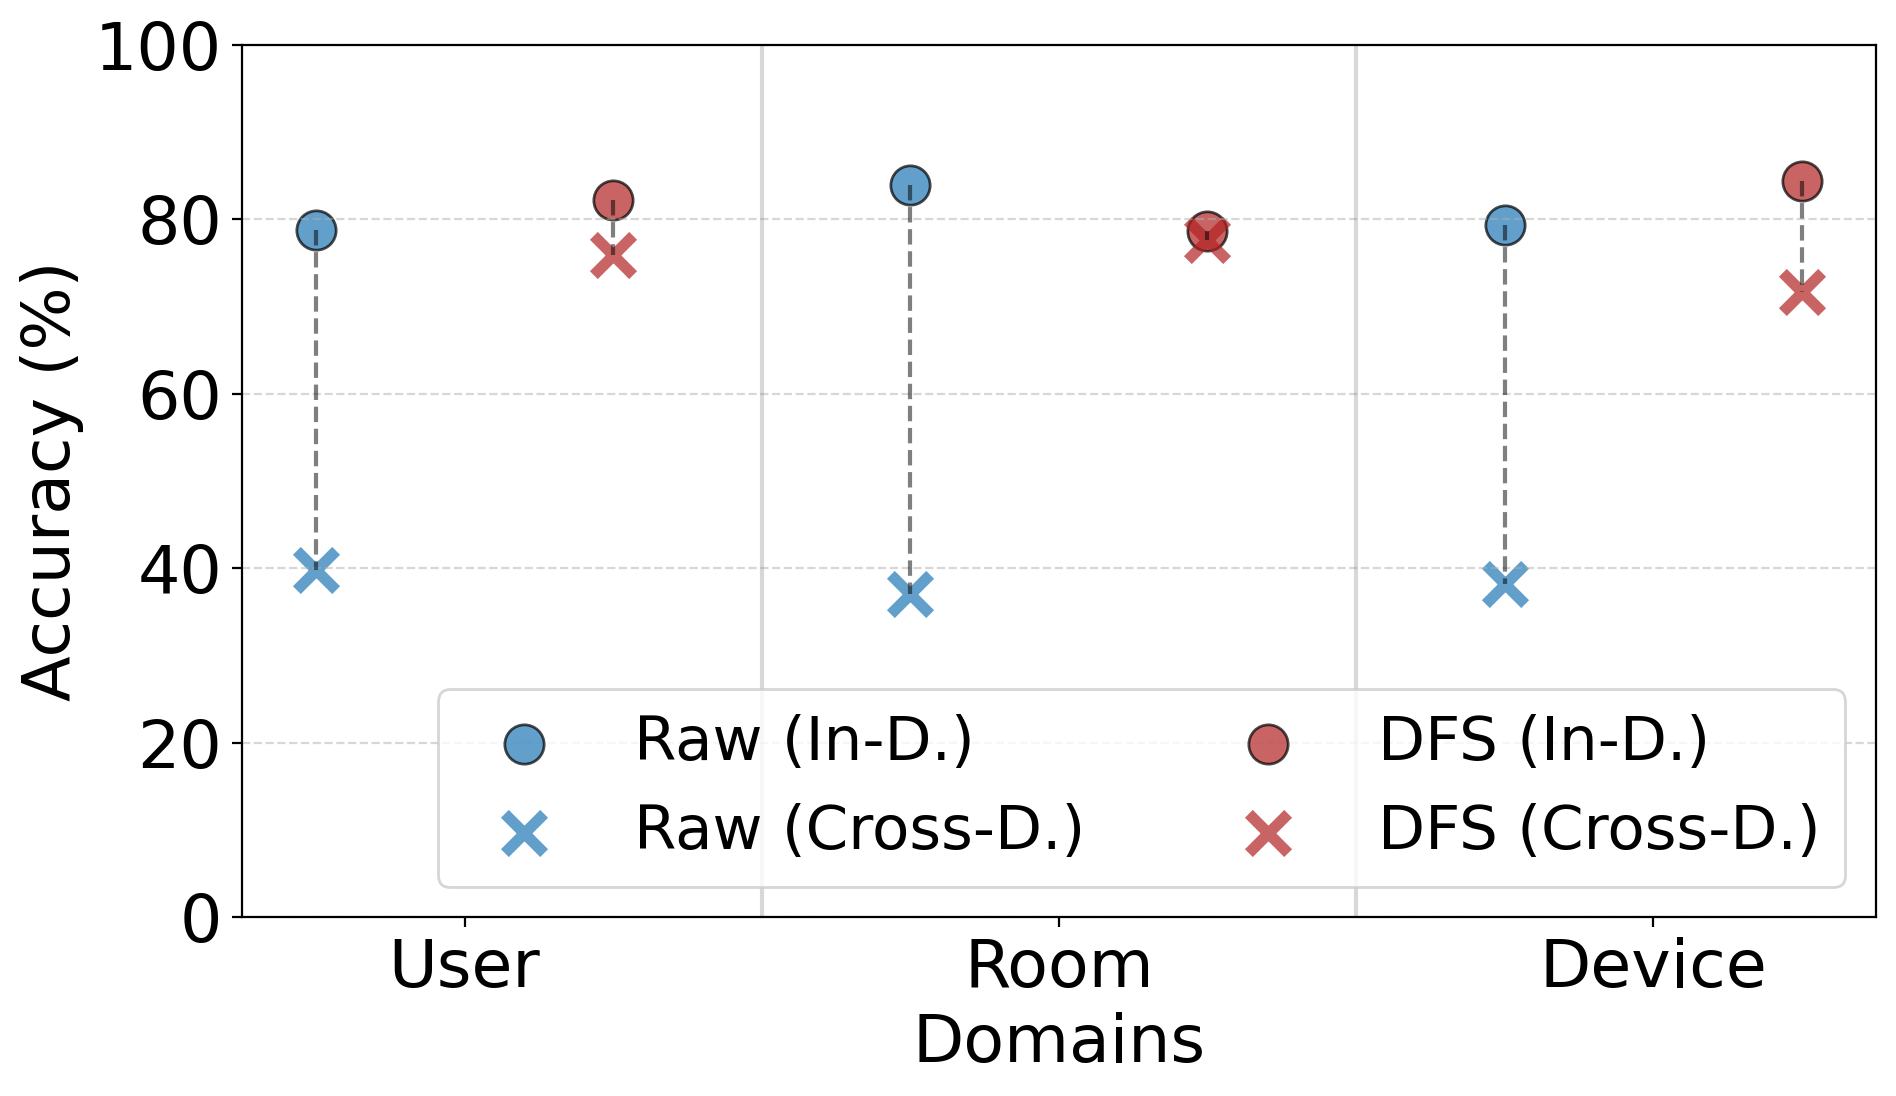

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data for plotting
categories = ['User', 'Room', 'Device']

# Mean accuracy values
csi_indomain = np.array([csi_c_user_indomain[0], csi_c_room_indomain[0], csi_c_device_indomain[0]])*100
csi_cross = np.array([csi_c_user[0], csi_c_room[0], csi_c_device[0]])*100
spec_indomain = np.array([spec_c_user_indomain[0], spec_c_room_indomain[0], spec_c_device_indomain[0]])*100
spec_cross = np.array([spec_c_user[0], spec_c_room[0], spec_c_device[0]])*100

plt.rcParams.update({'pdf.fonttype': 42})
plt.rcParams.update({'ps.fonttype': 42})
plt.rcParams.update({'font.size': 24}) 

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 6), dpi=200)

# Set positions
x_positions = []
for i in range(len(categories)):
    # CSI positions
    csi_pos = i * 3 + 0.75
    # STFT positions
    spec_pos = i * 3 + 2.25
    x_positions.append([csi_pos, spec_pos])

# Plot points with connecting lines
for i in range(len(categories)):
    # CSI points
    ax.scatter(x_positions[i][0], csi_indomain[i], s=200, color='tab:blue', marker='o', 
               label='Raw (In-D.)' if i == 0 else "", alpha=0.7, edgecolors='black')
    ax.scatter(x_positions[i][0], csi_cross[i], s=200, color='tab:blue', marker='x', 
               label='Raw (Cross-D.)' if i == 0 else "", alpha=0.7, linewidth=4)
    
    # STFT points
    ax.scatter(x_positions[i][1], spec_indomain[i], s=200, color='firebrick', marker='o', 
               label='DFS (In-D.)' if i == 0 else "", alpha=0.7, edgecolors='black')
    ax.scatter(x_positions[i][1], spec_cross[i], s=200, color='firebrick', marker='x', 
               label='DFS (Cross-D.)' if i == 0 else "", alpha=0.7, linewidth=4)
    
    # Connect in-domain to cross-domain with dashed lines
    ax.plot([x_positions[i][0], x_positions[i][0]], [csi_indomain[i], csi_cross[i]], 
            '--', alpha=0.5, color='black')
    ax.plot([x_positions[i][1], x_positions[i][1]], [spec_indomain[i], spec_cross[i]], 
            '--', alpha=0.5, color='black')
    
# Add vertical lines to separate categories
for i in range(1, len(categories)):
    ax.axvline(x=i*3, color='gray', linestyle='-', alpha=0.3)
# Set labels and title
ax.set_ylabel('Accuracy (%)')
ax.set_xlabel('Domains')
# Set x-ticks for categories
ax.set_xticks([i*3 + 1.5 for i in range(len(categories))])
ax.set_xticklabels(categories, fontsize=24)
# Set y-axis limits
ax.set_ylim(0, 100)

ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend(loc='lower right',  ncol=2, fontsize=22) # bbox_to_anchor=(0.5, -0.08),
plt.tight_layout()
# plt.subplots_adjust(bottom=0.15)
# plt.savefig("figures/v2_raw_csi_vs_stft" + ".pdf",dpi=200,bbox_inches = 'tight')
plt.show()